In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# EXAMPLE = 'apt0_body_state'
# IMG_NAME = 'kick-crop.jpeg'
# IMG_NAME = 'kick.jpeg'
# IMG_NAME = 'at-chair.jpeg'
# IMG_NAME = 'mid-air.jpg'
# IMG_NAME = 'pre-jump.jpg'

EXAMPLE = 'old_gw'
IMG_NAME = 'start.png'
# IMG_NAME = 'holding_milk.png'
# IMG_NAME = 'holding_cereal.png'
# IMG_NAME = 'cereal_in_container.png'
# IMG_NAME = 'milk_in_container.png'

# LLAMA_ID = "meta-llama/Meta-Llama-3-8B-Instruct"
LLAMA_ID = "meta-llama/Meta-Llama-3-70B-Instruct"
# LLAMA_ID = "meta-llama/Meta-Llama-3.1-8B-Instruct"

# LLAVA_ID = "liuhaotian/llava-v1.6-34b"
# LLAVA_ID = "lmms-lab/llava-onevision-qwen2-0.5b-si"
# LLAVA_ID = "lmms-lab/llava-onevision-qwen2-0.5b-ov"
# LLAVA_ID = "lmms-lab/llava-onevision-qwen2-7b-si"
LLAVA_ID = "lmms-lab/llava-onevision-qwen2-7b-ov"
# LLAVA_ID = "lmms-lab/llava-onevision-qwen2-72b-ov"

import warnings
warnings.filterwarnings("ignore")

In [3]:
from semantic_state_estimator.semantic_state_estimator import SemanticEstimatorMultiImageRun #SemanticStateEstimatorWithLLaMA

se = SemanticEstimatorMultiImageRun(
    domain=f'examples/{EXAMPLE}/domain.pddl',
    problem=f'examples/{EXAMPLE}/problem.pddl',
    nl_converter_model_id=LLAMA_ID,
    vqa_model_id=LLAVA_ID
)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


predicate queries loaded from cache
Loaded LLaVA model: lmms-lab/llava-onevision-qwen2-7b-ov


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
You are using a model of type llava to instantiate a model of type llava_qwen. This is not supported for all configurations of models and can yield errors.


Loading vision tower: google/siglip-so400m-patch14-384


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Model Class: LlavaQwenForCausalLM


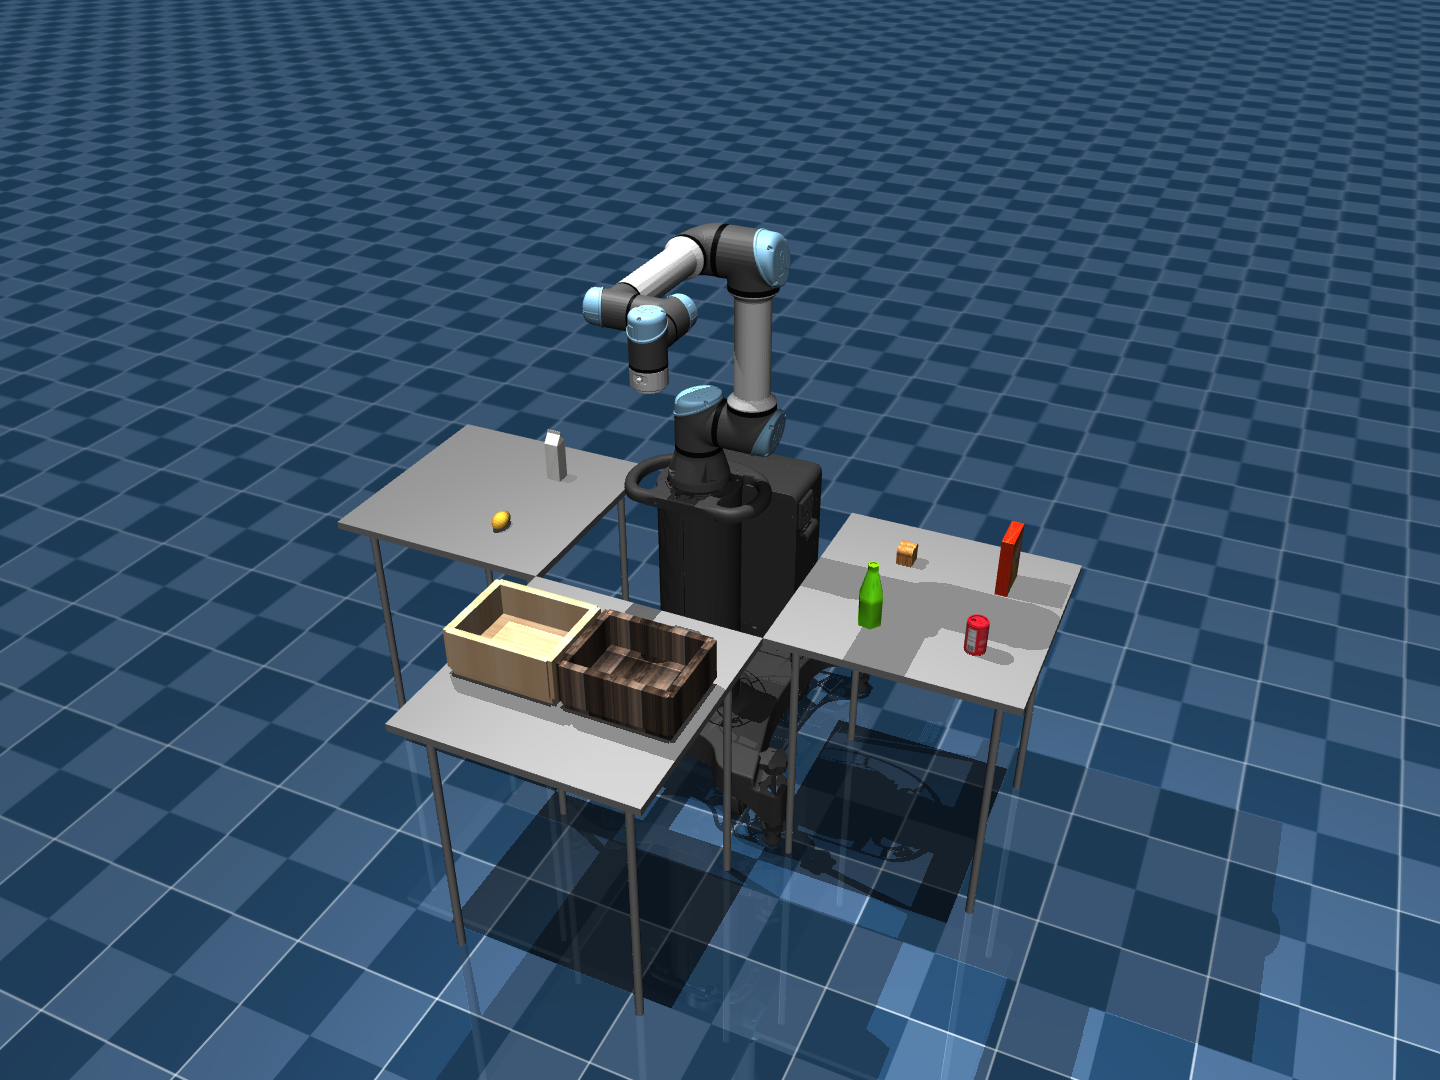

In [4]:
from PIL import Image

img = Image.open(f'examples/{EXAMPLE}/{IMG_NAME}')
img

In [ ]:
sorted([w for w in vqa.tokenizer.get_vocab() if 'false' in w.lower()])

In [ ]:
se([img])

In [5]:
prob_map = se.estimate_state([img])
prob_map

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

{'on-table(milk-carton)': 0.9600627422332764,
 'on-table(lemon)': 0.9962927103042603,
 'on-table(green-bottle)': 0.9995761513710022,
 'on-table(loaf-of-bread)': 0.9764905571937561,
 'on-table(red-box-of-cereal)': 0.8740772008895874,
 'on-table(red-can-of-soda)': 0.9805806279182434,
 'gripper-empty()': 0.982557475566864,
 'gripping(milk-carton)': 0.024798162281513214,
 'gripping(lemon)': 0.008124708198010921,
 'gripping(green-bottle)': 0.006641112267971039,
 'gripping(loaf-of-bread)': 0.004433765076100826,
 'gripping(red-box-of-cereal)': 0.0075772409327328205,
 'gripping(red-can-of-soda)': 0.0025708682369440794,
 'in-container(milk-carton,dark-wood-container)': 0.0005152656813152134,
 'in-container(milk-carton,light-wood-container)': 0.014503578655421734,
 'in-container(lemon,dark-wood-container)': 0.0014325366355478764,
 'in-container(lemon,light-wood-container)': 0.028007520362734795,
 'in-container(green-bottle,dark-wood-container)': 0.00011323438229737803,
 'in-container(green-bottl

In [ ]:
prob_map = se.estimate_state_par([img], batch_size=16)
prob_map

In [ ]:
state = set()
for pred, prob in prob_map.items():
    if prob > 0.5:
        state.add(pred)

state

In [ ]:
from PIL import ImageDraw, ImageFont

def display_res(query, output, img, save_path=None):
    img = img.copy()
    imd = ImageDraw.Draw(img)
    fnt = ImageFont.truetype("LiberationMono-Regular.ttf", 30)
    imd.text((28, 36), f'{query}: {output}', font=fnt, fill=(255, 0, 255))
    if save_path is None:
        img.show()
    else:
        img.save(save_path)

In [ ]:
from PIL import Image

image_files = [
    'start.png',
    'holding_milk.png',
    'holding_cereal.png',
    'milk_in_container.png',
    'cereal_in_container.png'
]
images = list(map(lambda imgf: Image.open(f'examples/{EXAMPLE}/{imgf}'), image_files))

In [ ]:
from tqdm.notebook import tqdm

for i, image in enumerate(tqdm(images)):
    prob_map = se.estimate_state_par([image], batch_size=4)
    for j, (pred, prob) in enumerate(tqdm(prob_map.items(), leave=False)):
        display_res(pred, f'{prob*100:.2f}%', image, save_path=f'demo/IMG{i}_pred{j}.png')

In [ ]:
for j, (pred, prob) in enumerate(tqdm(prob_map.items(), leave=False)):
    display_res(pred, f'{prob*100:.2f}%', images[-1])

In [ ]:
images[-1]

In [ ]:
img2 = Image.open(f'examples/apt0_body_state/kick-crop.jpeg')

In [ ]:
out = se.vqa_model([[img, img2], [img2, img]], ["describe the images", "describe the images please"])

In [ ]:
img2

In [ ]:
len(prob_map)

In [ ]:
se.queries_dict

In [ ]:
se.vqa_model('examples/apt0_body_state/right-foot-forward.jpeg', "Is the girl's left leg in front of her right leg?")

In [ ]:
probs = se.vqa_model('examples/apt0_body_state/right-foot-forward.jpeg', "Is the girl's left leg in front of her right leg?", get_probs=True)[-1]

In [ ]:
probs = se.vqa_model('examples/apt0_body_state/pre-jump.jpg', "Is the girl's left leg in front of her left leg?", get_probs=True)[-1]

In [ ]:
yes = probs[se.vqa_model.tokenizer.encode(['YES', 'yes', 'Yes'])].sum()
no = probs[se.vqa_model.tokenizer.encode(['NO', 'no', 'No'])].sum()

yes_prob = yes / (yes + no)
yes_prob.item()